## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [3]:
df=pd.read_csv("dirty_cafe_sales.csv")
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


### check 1st 5 rows

In [4]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


### check last 5 rows

In [5]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


### check all column names

In [6]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

### check Datatypes

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [8]:
df.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

### check statistical summary

In [9]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


### check null values/missing values

In [10]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [11]:
## Fill categorial column with mode
df['Item'] = df['Item'].fillna(df['Item'].mode()[0])
df['Payment Method'] = df['Payment Method'].fillna('Payment Method')
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])
df['Transaction Date'] = df['Transaction Date'].fillna(df['Transaction Date'].mode()[0])


In [ ]:
# convert columns to number
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [13]:
## Fill numerical column with median/mean
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].median())

In [14]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

### check Duplicates

In [15]:
df.duplicated().sum()

np.int64(0)

### check statistical summary

In [16]:
df.describe()

,Quantity,Price Per Unit,Total Spent
count,10000.000000,10000.00000,10000.00000
mean,3.027100,2.95265,8.87795
std,1.384614,1.24396,5.86059
min,1.000000,1.00000,1.00000
25%,2.000000,2.00000,4.00000
50%,3.000000,3.00000,8.00000
75%,4.000000,4.00000,12.00000
max,5.000000,5.00000,25.00000


### check histplot of all numeric column

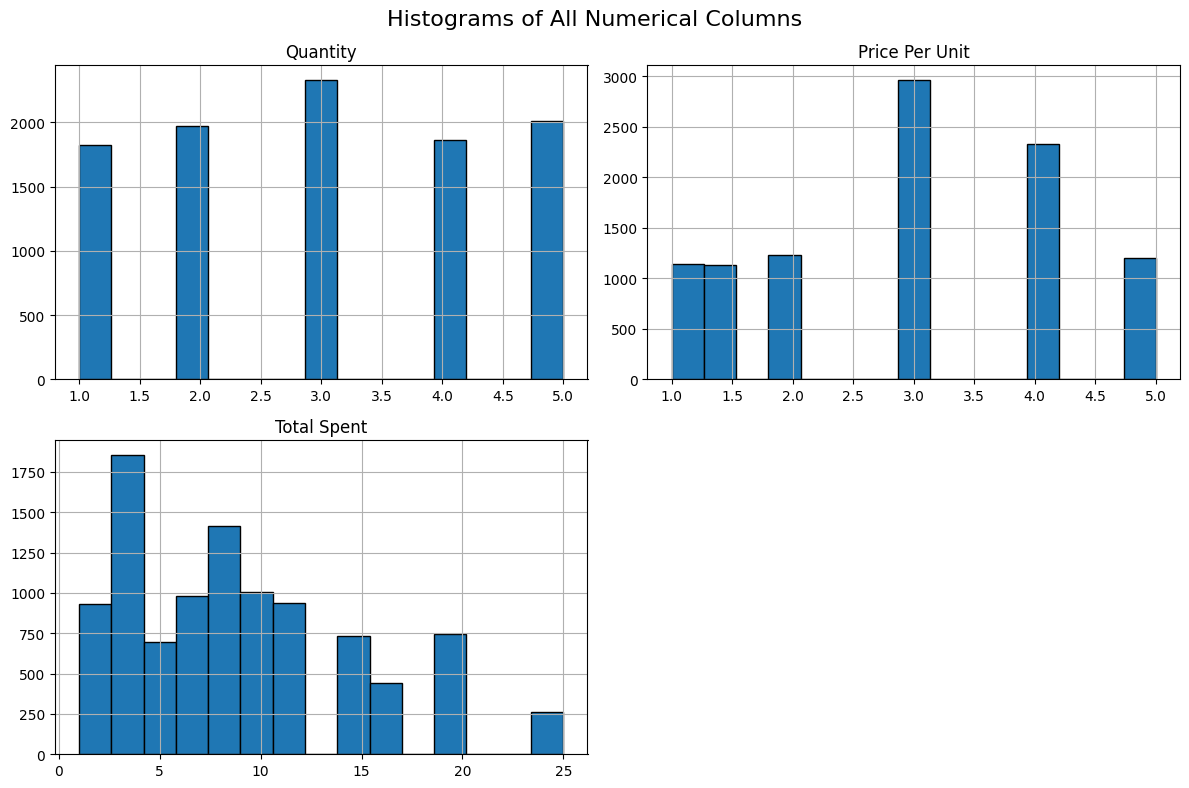

In [17]:
df.hist(figsize=(12, 8), bins=15, edgecolor='black')
plt.suptitle('Histograms of All Numerical Columns', fontsize=16)
plt.tight_layout()
plt.show()

### check Boxplot of all categorical column 

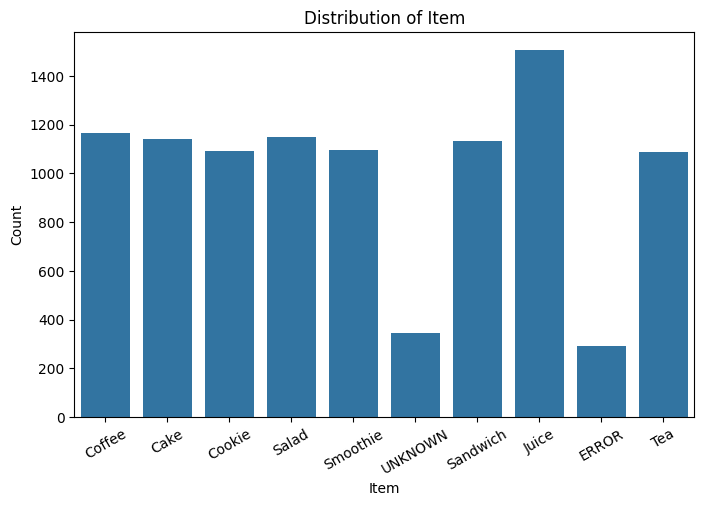

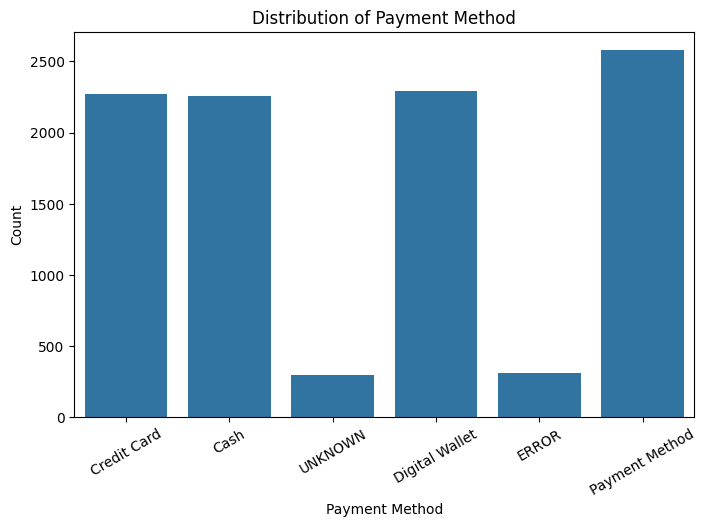

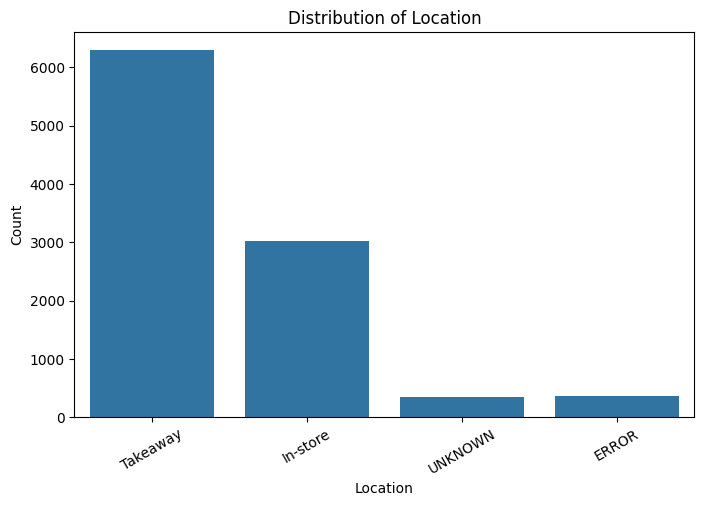

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = ['Item', 'Payment Method', 'Location']
for col in cat_cols:
    plt.figure(figsize=(8, 5)) 
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=30)  # Names clear dikhne ke liye rotation
    plt.show()

### check countplot of payment method and location

C:\Users\prime\AppData\Local\Temp\ipykernel_5476\3221851970.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Payment Method', ax=axes[0], palette='Blues_d')
C:\Users\prime\AppData\Local\Temp\ipykernel_5476\3221851970.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Location', ax=axes[1], palette='Oranges_d')


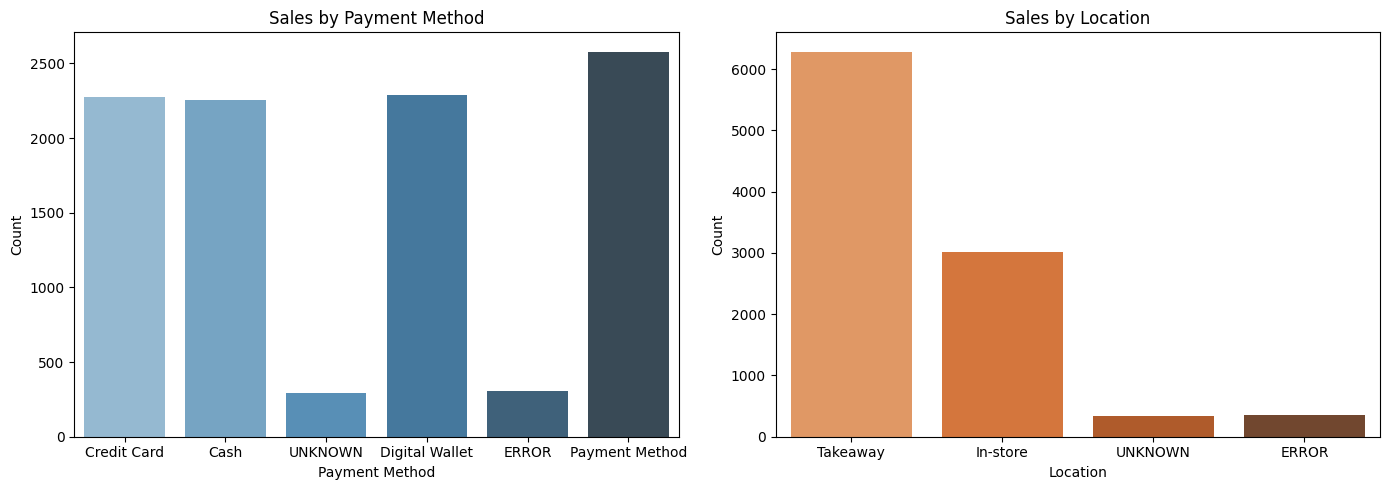

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Payment Method Graph
sns.countplot(data=df, x='Payment Method', ax=axes[0], palette='Blues_d')
axes[0].set_title('Sales by Payment Method')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Count')
# Location Graph
sns.countplot(data=df, x='Location', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Sales by Location')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

### check outliers by using interquartile Range

In [20]:
num_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Number of Outliers in '{col}': {len(outliers)}")

Number of Outliers in 'Quantity': 0
Number of Outliers in 'Price Per Unit': 0
Number of Outliers in 'Total Spent': 259


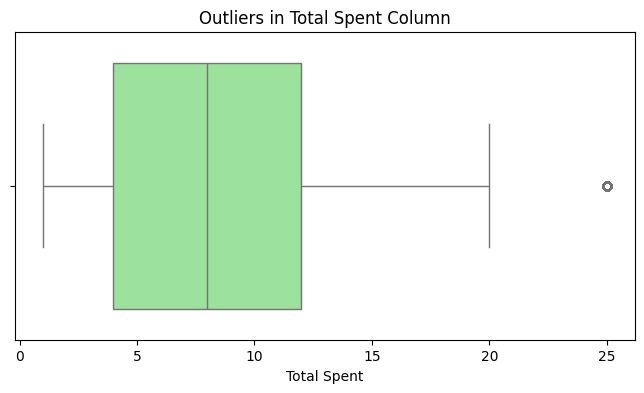

In [21]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Total Spent'], color='lightgreen')
plt.title('Outliers in Total Spent Column')
plt.show()

### check corelation Heatmap

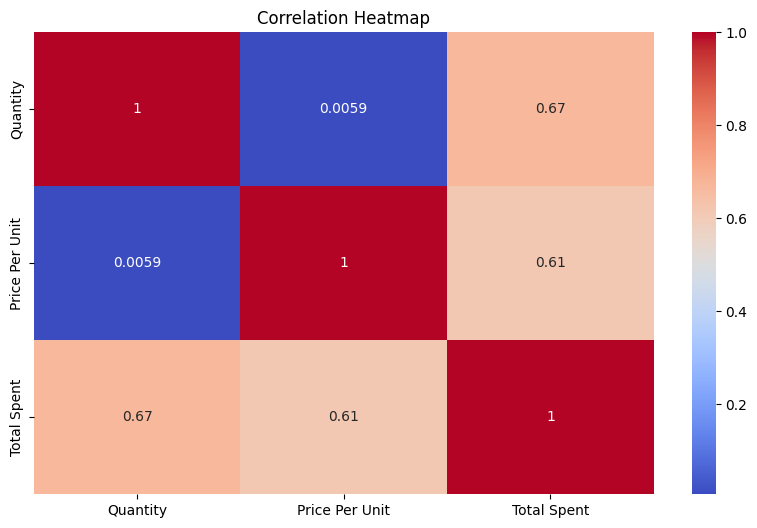

In [22]:
correlation = df.select_dtypes(include='number').corr()
correlation
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Key Insights & Executive Summary

Based on the exploratory data analysis (EDA) of the `dirty_cafe_sales.csv` dataset:
1. Dataset Overview & Integrity: The dataset consists of 10,000 transaction records. Zero duplicate rows were found, ensuring data uniqueness.
2. Data Cleaning & Imputation: Initial object data types were fixed. Missing values in numerical variables (`Quantity`, `Price Per Unit`, `Total Spent`) were handled using **median** imputation, while missing categorical values (`Item`, `Location`, `Payment Method`) were filled using **mode** imputation.
3. Transaction Metrics: The median quantity purchased per order is 3 units, with a mean total spent of approximately $8.88 per transaction.
4. Visual Distributions:
   - **Histograms** confirmed continuous numeric ranges, showing most customers purchase between 1 to 5 items per transaction.
   - Countplots revealed sales distribution patterns across various café items, primary payment channels, and store locations.
5. Outlier Analysis: IQR method and Boxplots identified 259 high-value transactions in `Total Spent`. These were retained as valid bulk or high-value orders rather than errors.


In [23]:
### Save cleaned Dataset
df.to_csv('cleaned_cafe_sales.csv', index=False)
print("Cleaned dataset successfully saved as 'cleaned_cafe_sales.csv'!")

Cleaned dataset successfully saved as 'cleaned_cafe_sales.csv'!
